# `TM_CCOEFF` + NMS: threshold (z) sweep, two ranking axes, TP/FP breakdown

**Purpose.** [`tm_score_distributions.ipynb`](tm_score_distributions.ipynb) showed *where*
the current `median + 0.5*MAD` extraction floor sits in the post-TM candidate distribution.
This notebook asks the next question: **what does moving that floor actually cost or buy**,
once the pipeline runs all the way through NMS and is scored against ground truth?

For each of the 7 domains, one `TM_CCOEFF` search (`hematoxylin_od` channel, no
rotation/scale augmentation -- the sweep's headline configuration) is matched, NMS'd, and
then evaluated at a **sweep of `z` levels** (`floor = map_median + z * mad_scale`). At every
`z` the surviving candidate pool is scored two ways:

* **`tm_score` axis** -- ranked by the search's own `TM_CCOEFF` value (the order NMS already
  produced).
* **`chromatin_od` axis** -- the same candidates re-ranked by chromatin density
  (`chromatin.rerank`), the signal `research logs 2026-09-01` found `TM_CCOEFF_NORMED` is
  mathematically blind to and which beats the correlation score as a *ranker* even though
  the search remains the *candidate generator*.

Ground truth is scored with the project's own harness (`evaluate.bucket_detections`,
`compare.evaluate_arms` -- the same machinery `premise_test.py` runs), so every number below
-- TP, FP (further split into look-alike vs. unannotated), precision, recall, reading depth
-- means exactly what it means everywhere else in this repo.

**One match per domain, not one match per `z`.** `tm.fused_response` is run once at a floor
deep enough to cover the whole sweep (`DEEP_FLOOR_Z`, below), NMS'd once, and each `z` level
is then a `score >= cut` filter of that one pool -- the "one-match-many-z" shortcut
`tm_variant_sweep.py`/`premise_test.py` both rely on and verify. This notebook re-verifies it
directly (below) rather than assuming it.

> **Corrected 2026-09-04.** This notebook was audited; see
> [`Research Logs/2026-09-03-tm-axis-sweep-audit.md`](Research%20Logs/2026-09-03-tm-axis-sweep-audit.md)
> for the findings and `2026-09-03-tm-axis-sweep-edit-plan.md` for the edits applied.
> The measurements below are unchanged (the saved CSV is byte-identical to commit
> `a52b403`); what changed is which of them are reported, and how they are read.


In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import chromatin as cm
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import invariants as inv
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from sklearn.neighbors import KDTree

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration

`CHANNEL`/`METHOD`/`BASE_SIZE`/no augmentation match the sweep's headline `TM_CCOEFF` arm
(`Research Logs/2026-09-01-tm-variant-sweep.md`, section 5) and the seed-selection rule
(pathologist-agreement pool, border-filtered, `default_rng([SEED_INDEX, image_id])`) matches
`tm_variant_sweep.draw_seeds`'s first of 5 independent streams -- the same seed
`tm_score_distributions.ipynb` used, so the two notebooks describe the same candidate
population.

`Z_LEVELS` sweeps both directions around the current production floor (`CURRENT_Z = 0.5`,
marked on every plot below) so "increasing *or* decreasing the threshold" is both visible.
`DEEP_FLOOR_Z` sits below every swept `z` so one match covers the whole sweep.

`BUDGETS` and the read-depth columns (`read_50`, `read_95`, ...) they produce are
`compare.py`'s own -- reading depth per click is the product metric
(`Research Logs`/project memory: AnnotateDx is a one-click-verify tool, so candidates a
pathologist must page through matters more than a fixed-threshold F1).

**One seed, one ROI per domain -- read every per-domain number as a single draw.**
`SEED_INDEX = 0` is one of `tm_variant_sweep.draw_seeds`' five streams, and
`compare.summarise`'s docstring is explicit: *"Never report a single-seed number
(Step 0 rule 5)."* `results/tm_ccoeff_headtohead_seed_variance.csv` measures the cost
on these exact ROIs with this exact method: `read_95` has a seed-to-seed SD of
260-2744 candidates, and seed 0 happens to land on the **maximum** of the five-seed
distribution for `301.tiff` and the **minimum** for `246.tiff` and `548.tiff`. Nothing
below that compares two per-domain reading depths is resolvable at this sample size;
the cross-domain patterns and the within-run z comparisons are.


In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
BASE_SIZE = tm.BASE_SIZE
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0                                        # tm_variant_sweep's first seed stream
SELF_HIT_RADIUS = 5.0

Z_LEVELS = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
CURRENT_Z = 0.5                                        # med + 0.5*mad, the extraction-floor
                                                       # convention of tm_variant_sweep.FLOOR_Z
                                                       # and premise_test.py -- NOT
                                                       # FSConfig.score_threshold=0.5, which is a
                                                       # raw TM_CCOEFF_NORMED score that happens
                                                       # to share the number. (The operating
                                                       # point later moved to z=1.0, decided in
                                                       # tp_fp_score_distribution.ipynb.)
DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5                     # strictly below the sweep -> one match covers it
MAX_PEAKS = 2_000_000                                  # far above any ROI's local-max count

BUDGETS = cp.BUDGETS                                   # (25, 50, 100, 250, 500, 1000, 2000, 5000)
AXES = ('tm_score', 'chromatin_od')
AXIS_RANK_KEY = {'tm_score': 'score', 'chromatin_od': 'od'}
AXIS_COLOR = {'tm_score': '#4c72b0', 'chromatin_od': '#c44e52'}

CFG = fs.FSConfig(channel=CHANNEL, base_size=BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2

## One ROI per domain

Same rule as `tm_score_distributions.ipynb`: the downloaded image with the most mitotic
figures in each domain (`experiment.select_domain_images`).

In [3]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)
domain_images[['tumor_type', 'file_name', 'image_id', 'n_mitotic']]

,tumor_type,file_name,image_id,n_mitotic
0,canine cutaneous mast cell tumor,301.tiff,301,218
1,canine lung cancer,201.tiff,201,18
2,canine lymphosarcoma,246.tiff,246,116
3,canine soft tissue sarcoma,459.tiff,459,131
4,human breast cancer,094.tiff,94,82
5,human melanoma,548.tiff,548,239
6,human neuroendocrine tumor,402.tiff,402,105


## Match once, NMS once, sweep `z`, rank two ways, score against ground truth

Per domain: load the ROI, match at `DEEP_FLOOR_Z`, NMS at the image's own evaluation match
radius (`evaluate.radius_px(mpp)`), drop the seed's self-hit, then chromatin-score the
survivors once (`chromatin.score_detections`) -- that one pool is reused for every `z`.

The shortcut is checked, not assumed: at `z = CURRENT_Z` the deep pool is re-filtered and
compared against a fresh `extract_peaks` + NMS run at that cut's exact score; the two
coordinate sets must match exactly (`invariants`-style strict check, mirroring
`premise_test.verify_shortcut`).

For each `z`, both axes (`tm_score`, `chromatin_od`) are built as `compare.Arm`s over the
*same* `score >= cut` subset and scored with `compare.evaluate_arms` against the same
`gt_eval` (ground truth with the seed annotation removed) -- so the only thing that differs
between the two rows at a given `(domain, z)` is the order candidates are ranked in.

In [4]:
all_rows = []
shortcut_checks = []
diag_rows = []

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    radius = ev.radius_px(mpp)
    hem = ch.to_channel(rgb, CHANNEL)
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = pool_seed.iloc[int(rng.integers(len(pool_seed)))]
    seed_xy = (float(seed['cx']), float(seed['cy']))
    gt_eval = gt[gt['ann_id'] != int(seed['ann_id'])].reset_index(drop=True)

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, CFG.base_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)
    fused, best, valid = tm.fused_response(hem, templates, CFG.scale_normalize, method=METHOD)
    med, mad = tm.robust_stats(fused, valid)
    deep_floor = med + DEEP_FLOOR_Z * mad

    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)
    keep = nms_by_distance(centers, scores, radius)
    centers, scores = centers[keep], scores[keep]
    ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    centers, scores = centers[ok], scores[ok]

    pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    pool = cm.score_detections(pool, hem)

    # --- re-verify the one-match-many-z shortcut at CURRENT_Z, not just assume it ---
    check_cut = med + CURRENT_Z * mad
    c2, s2 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, check_cut, MAX_PEAKS)
    k2 = nms_by_distance(c2, s2, radius)
    c2 = c2[k2]
    ok2 = np.hypot(c2[:, 0] - seed_xy[0], c2[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    direct = c2[ok2]
    filtered = pool.loc[pool['score'] >= check_cut, ['cx', 'cy']].to_numpy()
    a = direct[np.lexsort((direct[:, 1], direct[:, 0]))] if len(direct) else direct
    b = filtered[np.lexsort((filtered[:, 1], filtered[:, 0]))] if len(filtered) else filtered
    shortcut_ok = (a.shape == b.shape) and bool(np.allclose(a, b))
    shortcut_checks.append({'file_name': fn, 'domain': domain, 'z_checked': CURRENT_Z,
                            'n_direct': len(direct), 'n_filtered': len(filtered),
                            'passed': shortcut_ok})

    # --- duplicate-detection diagnostic (Finding 8) ---
    # NMS runs at the evaluation match radius here, which is what `invariants.check_nms_radius`
    # requires. Even so, two kept detections can both fall inside one GT's match circle, and the
    # second is bucketed `non_human_findings` -- a false positive that is really a duplicate.
    # This is the invariant-compliant baseline the v2 notebook's decoupled radius is compared to.
    # Kept in a side list, NOT in `ctx`: `compare.evaluate_arms` does `base = dict(context)`, so
    # every ctx key becomes a CSV column and would change the saved schema.
    pool_sorted = pool.sort_values('score', ascending=False).reset_index(drop=True)
    det_bucketed, _ = ev.bucket_detections(pool_sorted, gt_eval, radius)
    d_gt, _ = KDTree(gt_eval[['cx', 'cy']].to_numpy()).query(
        det_bucketed[['cx', 'cy']].to_numpy(), k=1)
    inside_gt = d_gt[:, 0] <= radius
    dup_fp = inside_gt & (det_bucketed['bucket'] == ev.NON_HUMAN_FINDINGS).to_numpy()
    diag_rows.append({'file_name': fn, 'tumor_type': domain, 'n_detections': len(pool),
                      'n_within_match_radius': int(inside_gt.sum()),
                      'n_dup_fp': int(dup_fp.sum())})

    ctx = {'file_name': fn, 'image_id': image_id, 'tumor_type': domain,
          'mpp': round(mpp, 4), 'seed_ann_id': int(seed['ann_id']),
          'map_median': round(med, 5), 'mad_scale': round(mad, 5),
          'deep_floor': round(deep_floor, 5), 'n_pool': len(pool)}

    arms = []
    for z in Z_LEVELS:
        cut = med + z * mad
        sub = pool[pool['score'] >= cut]
        limited = bool(cut < deep_floor)
        for axis in AXES:
            arms.append(cp.Arm(
                axis, (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis], seeded=True, z=z,
                z_dependent=True, floor_limited=limited, nms_radius=radius,
                caps=(MAX_PEAKS,), extra={'axis': axis, 'z_cut': round(cut, 5)}))

    got = cp.evaluate_arms(arms, gt_eval, radius, roi_shape=rgb.shape, mpp=mpp,
                           budgets=BUDGETS, context=ctx)
    all_rows.append(got)

    print(f"[{fn}] {domain:34s} n_pool={len(pool):6d} median={med:+.4f} mad={mad:.4f} "
          f"shortcut_ok={shortcut_ok} [{time.time() - t0:.0f}s]", flush=True)

    del rgb, hem, fused, best, valid
    import gc; gc.collect()

results = pd.concat(all_rows, ignore_index=True)
cp.assert_floor_not_limiting(results)
shortcut_df = pd.DataFrame(shortcut_checks)
diag_df = pd.DataFrame(diag_rows)
print(f'\ntotal {time.time() - NB_T0:.0f}s, {len(results)} rows, '
     f'shortcut passed {shortcut_df["passed"].sum()}/{len(shortcut_df)} domains')
shortcut_df

[301.tiff] canine cutaneous mast cell tumor   n_pool= 17316 median=-0.0176 mad=0.2795 shortcut_ok=True [11s]


[201.tiff] canine lung cancer                 n_pool= 15549 median=-0.0283 mad=0.6125 shortcut_ok=True [9s]


[246.tiff] canine lymphosarcoma               n_pool= 17397 median=-0.0057 mad=0.1935 shortcut_ok=True [8s]


[459.tiff] canine soft tissue sarcoma         n_pool= 15445 median=-0.1598 mad=1.2429 shortcut_ok=True [7s]


[094.tiff] human breast cancer                n_pool= 16755 median=-0.0108 mad=0.1188 shortcut_ok=True [11s]


[548.tiff] human melanoma                     n_pool= 15897 median=-0.2213 mad=1.5145 shortcut_ok=True [12s]


[402.tiff] human neuroendocrine tumor         n_pool= 16360 median=-0.1138 mad=1.9103 shortcut_ok=True [11s]



total 75s, 1008 rows, shortcut passed 7/7 domains


,file_name,domain,z_checked,n_direct,n_filtered,passed
0,301.tiff,canine cutaneous mast cell tumor,0.5,16871,16871,True
1,201.tiff,canine lung cancer,0.5,14330,14330,True
2,246.tiff,canine lymphosarcoma,0.5,17105,17105,True
3,459.tiff,canine soft tissue sarcoma,0.5,14216,14216,True
4,094.tiff,human breast cancer,0.5,15161,15161,True
5,548.tiff,human melanoma,0.5,14492,14492,True
6,402.tiff,human neuroendocrine tumor,0.5,15625,15625,True


## Persist the raw sweep

One row per `(domain, axis, z, budget)`. Written alongside the rest of `results/` so the
sweep does not need re-running to revisit a specific cut.

In [5]:
import pathlib
pathlib.Path('results').mkdir(exist_ok=True)
out_path = 'results/tm_ccoeff_threshold_axis_sweep.csv'
results.to_csv(out_path, index=False)
print('wrote', out_path, results.shape)
results.head(3)

wrote results/tm_ccoeff_threshold_axis_sweep.csv (1008, 37)


,file_name,image_id,tumor_type,mpp,seed_ann_id,map_median,mad_scale,deep_floor,n_pool,arm,rank_key,seeded,z,z_dependent,floor_limited,n_gt_mitotic,n_gt_lookalike,n_detections,coverage_frac,n_lookalike_in_list,largest_tie_block,nan_rate,full_list_recall,match_radius_px,read_50,read_80,read_90,read_95,read_99,read_100,axis,z_cut,budget,budget_delivered,tp_at_budget,lookalike_at_budget,recall_at_budget
0,301.tiff,301,canine cutaneous mast cell tumor,0.2533,14969,-0.01756,0.27946,-0.43675,17316,tm_score,score,True,-1.0,True,False,217,109,17316,0.9496,102,2,0.0,0.97235,29.609,526.0,4161.0,6763.0,10389.0,NaN,NaN,tm_score,-0.29702,25,25,17,2,0.078341
1,301.tiff,301,canine cutaneous mast cell tumor,0.2533,14969,-0.01756,0.27946,-0.43675,17316,tm_score,score,True,-1.0,True,False,217,109,17316,0.9496,102,2,0.0,0.97235,29.609,526.0,4161.0,6763.0,10389.0,NaN,NaN,tm_score,-0.29702,50,50,32,5,0.147465
2,301.tiff,301,canine cutaneous mast cell tumor,0.2533,14969,-0.01756,0.27946,-0.43675,17316,tm_score,score,True,-1.0,True,False,217,109,17316,0.9496,102,2,0.0,0.97235,29.609,526.0,4161.0,6763.0,10389.0,NaN,NaN,tm_score,-0.29702,100,100,57,9,0.262673


## Full-list composition is (almost) axis-independent -- check, don't assume

`tm_score` and `chromatin_od` rank the *same* candidate set at a given `(domain, z)`; only
their order differs. `evaluate.bucket_detections` matches greedily in rank order, so the
**only** way axis choice can change a full-list TP/FP count is a contested ground-truth
point with more than one candidate detection inside its match radius, where the order
decides which candidate claims it. This is checked directly below rather than asserted --
any row that fails is a concrete instance of that contested-match effect, not a bug.

In [6]:
full = results.drop_duplicates(['file_name', 'tumor_type', 'arm', 'z']).copy()
full['tp_full'] = (full['full_list_recall'] * full['n_gt_mitotic']).round().astype(int)
full['fp_lookalike_full'] = full['n_lookalike_in_list']
full['fp_unannotated_full'] = full['n_detections'] - full['tp_full'] - full['fp_lookalike_full']
full['precision_full'] = full['tp_full'] / full['n_detections'].replace(0, np.nan)

wide = full.pivot_table(index=['file_name', 'z'], columns='arm',
                        values=['tp_full', 'fp_lookalike_full', 'n_detections'])
mismatch = wide[(wide['tp_full']['tm_score'] != wide['tp_full']['chromatin_od']) |
                (wide['fp_lookalike_full']['tm_score'] != wide['fp_lookalike_full']['chromatin_od'])]
print(f'{len(mismatch)} / {len(wide)} (file, z) cells have axis-dependent full-list counts '
     '(contested-match tie-breaks)')
if len(mismatch):
    mismatch

0 / 63 (file, z) cells have axis-dependent full-list counts (contested-match tie-breaks)


## Full-list candidate composition vs. `z` -- axis-independent view

One panel per domain. Stacked bars are counts (log-scaled y) of true positives, look-alike
false positives and unannotated false positives in the **entire** surviving pool at that
`z` (using the `tm_score` axis rows -- per the check above, totals are the same on the
`chromatin_od` axis in every domain unless flagged there). The line is full-list precision.
`CURRENT_Z` (the shipped `median + 0.5*MAD` floor) is marked.

**Read this against the coverage table further down, not alone.** Across the nine `z`
levels plotted here `n_detections` spans **3,070-17,397** and `coverage_frac` spans
**0.256-0.951** -- so at the loose end the detection list tiles the ROI more finely
than the match radius can resolve, and "was this annotation found" is being answered
by geometry. `precision_full` spans **0.109%-4.87%** over the same panels: with 13k-17k
detections against ~200 mitoses it is measuring list *length* far more than list
quality, and the shape of its curve is close to `1 / n_detections`.


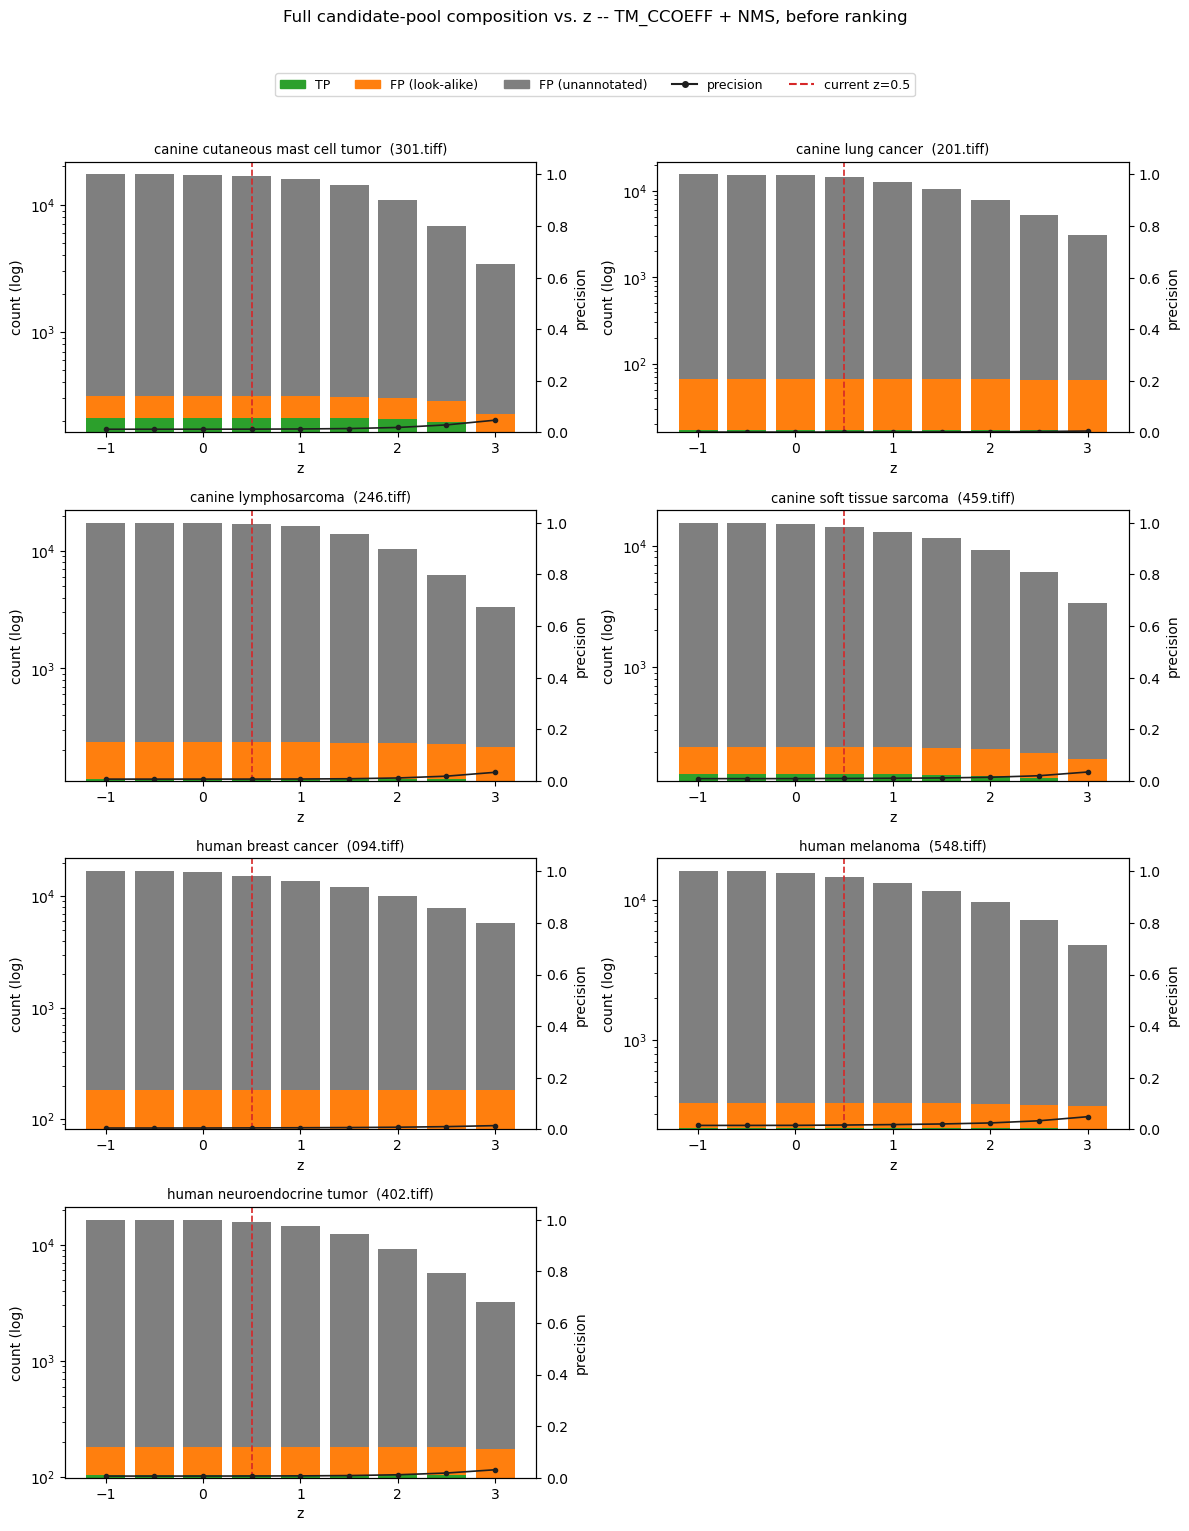

In [7]:
comp = full[full['arm'] == 'tm_score'].sort_values(['tumor_type', 'z'])
domains = sorted(comp['tumor_type'].unique())
n = len(domains)
ncols = 2
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, domain in zip(axes, domains):
    d = comp[comp['tumor_type'] == domain]
    zs = d['z'].to_numpy()
    ax.bar(zs, d['tp_full'], width=0.4, label='TP', color='#2ca02c')
    ax.bar(zs, d['fp_lookalike_full'], width=0.4, bottom=d['tp_full'],
          label='FP (look-alike)', color='#ff7f0e')
    bottom2 = d['tp_full'] + d['fp_lookalike_full']
    ax.bar(zs, d['fp_unannotated_full'], width=0.4, bottom=bottom2,
          label='FP (unannotated)', color='#7f7f7f')
    ax.set_yscale('log')
    ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.2)
    ax2 = ax.twinx()
    ax2.plot(zs, d['precision_full'], color='#1f1f1f', marker='o', markersize=3,
            linewidth=1.2, label='precision')
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('precision')
    ax.set_title(f"{domain}  ({d['file_name'].iloc[0]})", fontsize=9.5)
    ax.set_xlabel('z')
    ax.set_ylabel('count (log)')

for ax in axes[n:]:
    ax.set_visible(False)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Patch(color='#2ca02c', label='TP'),
    Patch(color='#ff7f0e', label='FP (look-alike)'),
    Patch(color='#7f7f7f', label='FP (unannotated)'),
    Line2D([0], [0], color='#1f1f1f', marker='o', markersize=4, label='precision'),
    Line2D([0], [0], color='#d62728', linestyle='--', label='current z=0.5'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=5,
          bbox_to_anchor=(0.5, 1.02), fontsize=9)
fig.suptitle('Full candidate-pool composition vs. z -- TM_CCOEFF + NMS, before ranking',
            y=1.06, fontsize=12)
fig.tight_layout()
plt.show()

## Pool size vs. `z`, all domains overlaid

The denominator behind every precision number above -- how aggressively each step of `z`
actually shrinks the surviving candidate list, per domain.

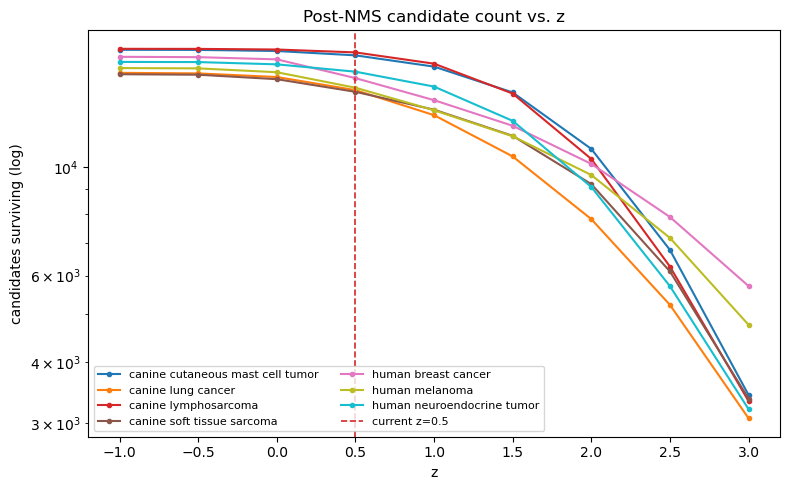

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n))
for domain, color in zip(domains, colors):
    d = comp[comp['tumor_type'] == domain]
    ax.plot(d['z'], d['n_detections'], marker='o', markersize=3, color=color, label=domain)
ax.set_yscale('log')
ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.2, label='current z=0.5')
ax.set_xlabel('z')
ax.set_ylabel('candidates surviving (log)')
ax.set_title('Post-NMS candidate count vs. z')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Reading depth to reach mitotic recall -- both axes

`read_50` / `read_95`: candidates a pathologist reads (top of the ranked list, in order) to
reach 50% / 95% mitotic recall in that domain. Lower is better and this is the number the
product cares about (verifying one detection is cheaper than missing one, but every extra
candidate read costs pathologist time). Solid = `read_50`, dashed = `read_95`; colour is the
ranking axis. Where `chromatin_od` sits below `tm_score` at the same `z`, re-ranking by
chromatin density is buying reading depth for free -- no re-match required.

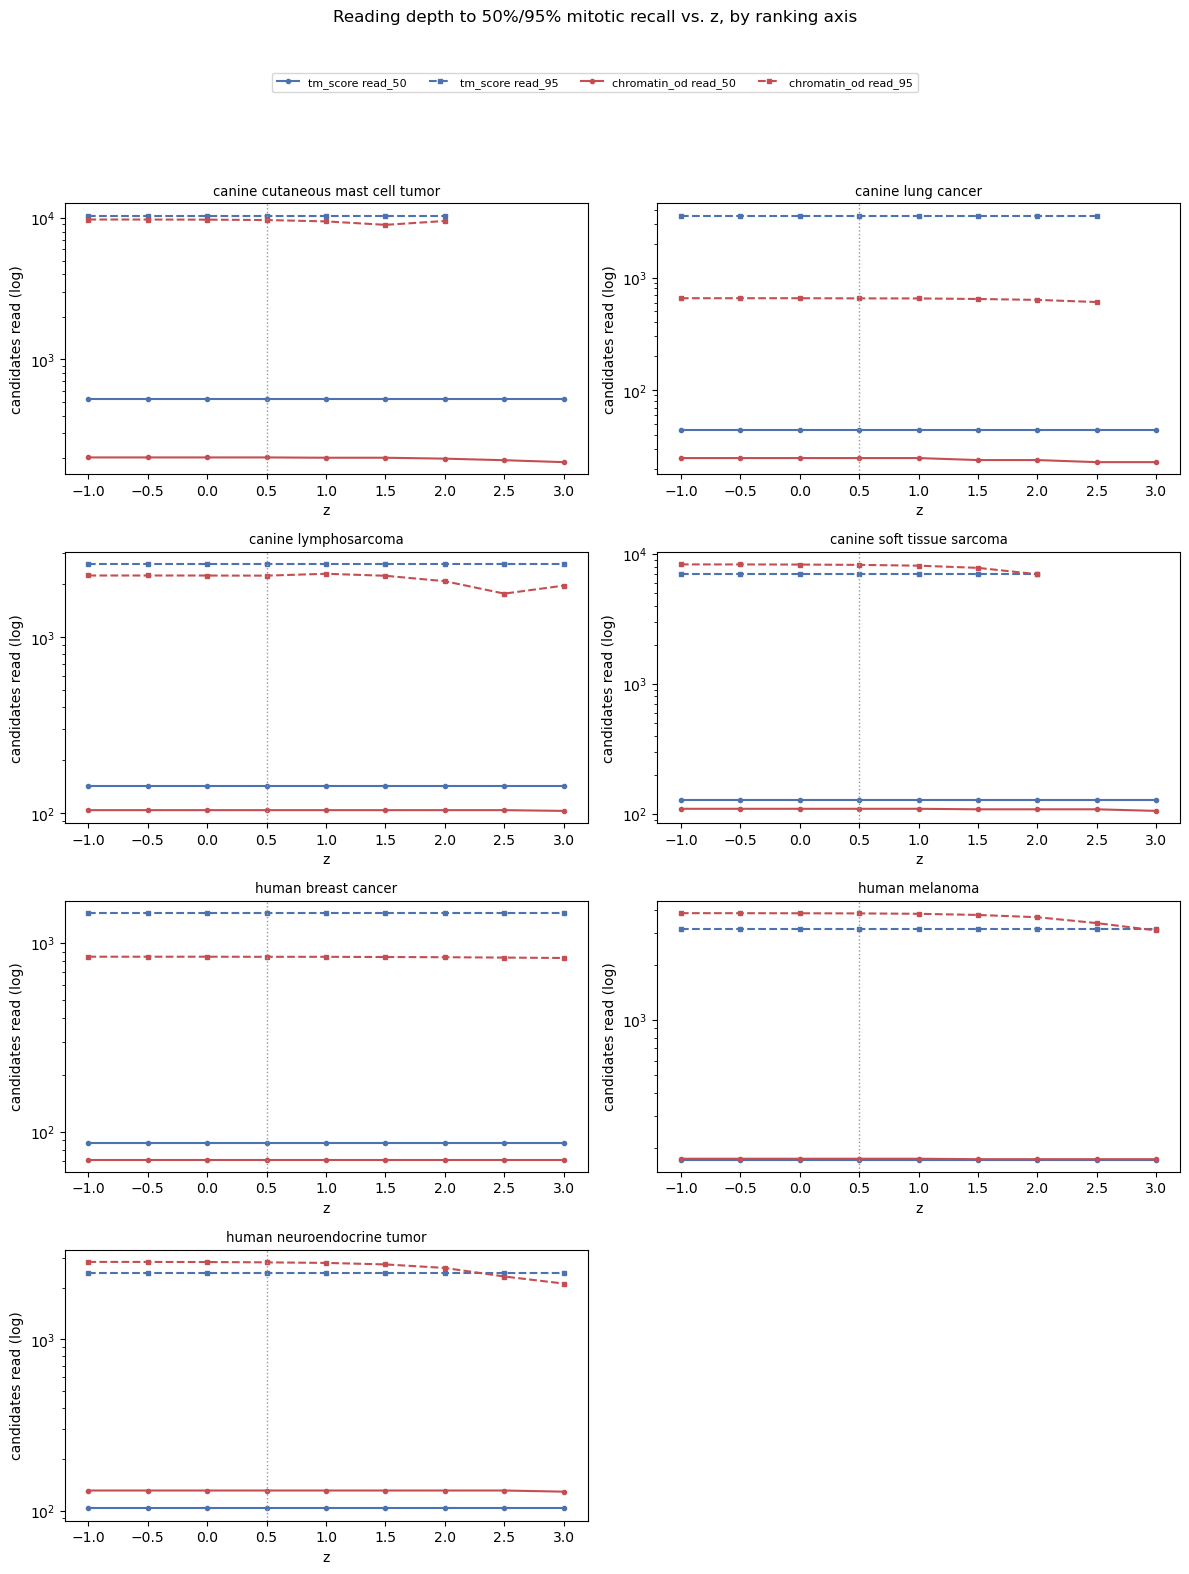

In [9]:
rd = results.drop_duplicates(['file_name', 'tumor_type', 'arm', 'z']).copy()
fig, axes2 = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows))
axes2 = np.atleast_1d(axes2).ravel()

for ax, domain in zip(axes2, domains):
    for axis in AXES:
        d = rd[(rd['tumor_type'] == domain) & (rd['arm'] == axis)].sort_values('z')
        ax.plot(d['z'], d['read_50'], color=AXIS_COLOR[axis], linestyle='-', marker='o',
               markersize=3, label=f'{axis} read_50')
        ax.plot(d['z'], d['read_95'], color=AXIS_COLOR[axis], linestyle='--', marker='s',
               markersize=3, label=f'{axis} read_95')
    ax.set_yscale('log')
    ax.axvline(CURRENT_Z, color='#999999', linestyle=':', linewidth=1.0)
    ax.set_title(f"{domain}", fontsize=9.5)
    ax.set_xlabel('z')
    ax.set_ylabel('candidates read (log)')

for ax in axes2[n:]:
    ax.set_visible(False)

handles, labels = axes2[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=8)
fig.suptitle('Reading depth to 50%/95% mitotic recall vs. z, by ranking axis', y=1.09, fontsize=12)
fig.tight_layout()
plt.show()

## Recall at a fixed reading budget, both axes

The other half of the reading-depth question: *given* a pathologist reads exactly `K`
candidates, how much mitotic recall do they get -- and does that change with `z` or with
which axis ranks the list? `K = 100` is used as one representative short-list budget;
`results` has every budget in `compare.BUDGETS` for any other value.

**The `tm_score` curve is flat by construction; only `chromatin_od` is a live
comparison here.** Raising the floor deletes only *lower-scoring* candidates, and the
`tm_score` axis ranks by that same score -- so the top-K it hands the reader cannot
change while the surviving list is still longer than K. It always is: the smallest
pool anywhere in this grid is 3,070 (canine lung cancer, `z=3.0`), 30x the K=100
plotted. The cell above asserts this rather than asking you to take it on trust, and
shows that the identity genuinely fails on `chromatin_od`, where a *score* filter
removes entries from arbitrary positions in an *od*-ranked list.


### First: is there anything for `z` to change at this budget?

Check before plotting, rather than reading a flat line off a figure and wondering. The
claim is that on the `tm_score` axis `recall_at_budget` is *invariant* in `z` wherever
the surviving pool is longer than the budget -- because filtering by score cannot
reorder a list already ranked by that score. The arm restriction is the whole content:
the same statement is false on `chromatin_od`, where a score filter deletes entries
from arbitrary positions in an od-ranked list. Both are measured below.

In [10]:
def _z_spread(arm):
    s = results[(results['arm'] == arm) & (results['n_detections'] >= results['budget'])]
    return s.groupby(['tumor_type', 'budget'])['recall_at_budget'].apply(
        lambda x: float(np.ptp(x.to_numpy())))

sp_tm, sp_od = _z_spread('tm_score'), _z_spread('chromatin_od')
assert (sp_tm < 1e-12).all(), 'tm_score recall_at_budget moved with z on an untruncated pool'
print(f"tm_score    : {len(sp_tm)} (domain, budget) groups with n_detections >= budget, "
      f"{int((sp_tm > 1e-12).sum())} vary with z (max spread {sp_tm.max():.3e})")
print(f"chromatin_od: {len(sp_od)} groups, {int((sp_od > 1e-12).sum())} vary with z "
      f"(max spread {sp_od.max():.4f})   <- the contrast is the point")

i = results['n_detections'].idxmin()
print(f"\nsmallest pool anywhere in the grid: {int(results.loc[i, 'n_detections'])} "
      f"({results.loc[i, 'tumor_type']}, z={results.loc[i, 'z']}) = "
      f"{int(results.loc[i, 'n_detections']) // 100}x the K=100 budget plotted below")
tr = results[(results['arm'] == 'tm_score') & (results['n_detections'] < results['budget'])]
print(f"the pool truncates only at budget {sorted(tr['budget'].unique())}, "
      f"z {sorted(tr['z'].unique())}, in {tr['tumor_type'].nunique()} of 7 domains")

tm_score    : 56 (domain, budget) groups with n_detections >= budget, 0 vary with z (max spread 0.000e+00)
chromatin_od: 56 groups, 33 vary with z (max spread 0.0968)   <- the contrast is the point

smallest pool anywhere in the grid: 3070 (canine lung cancer, z=3.0) = 30x the K=100 budget plotted below
the pool truncates only at budget [5000], z [3.0], in 6 of 7 domains


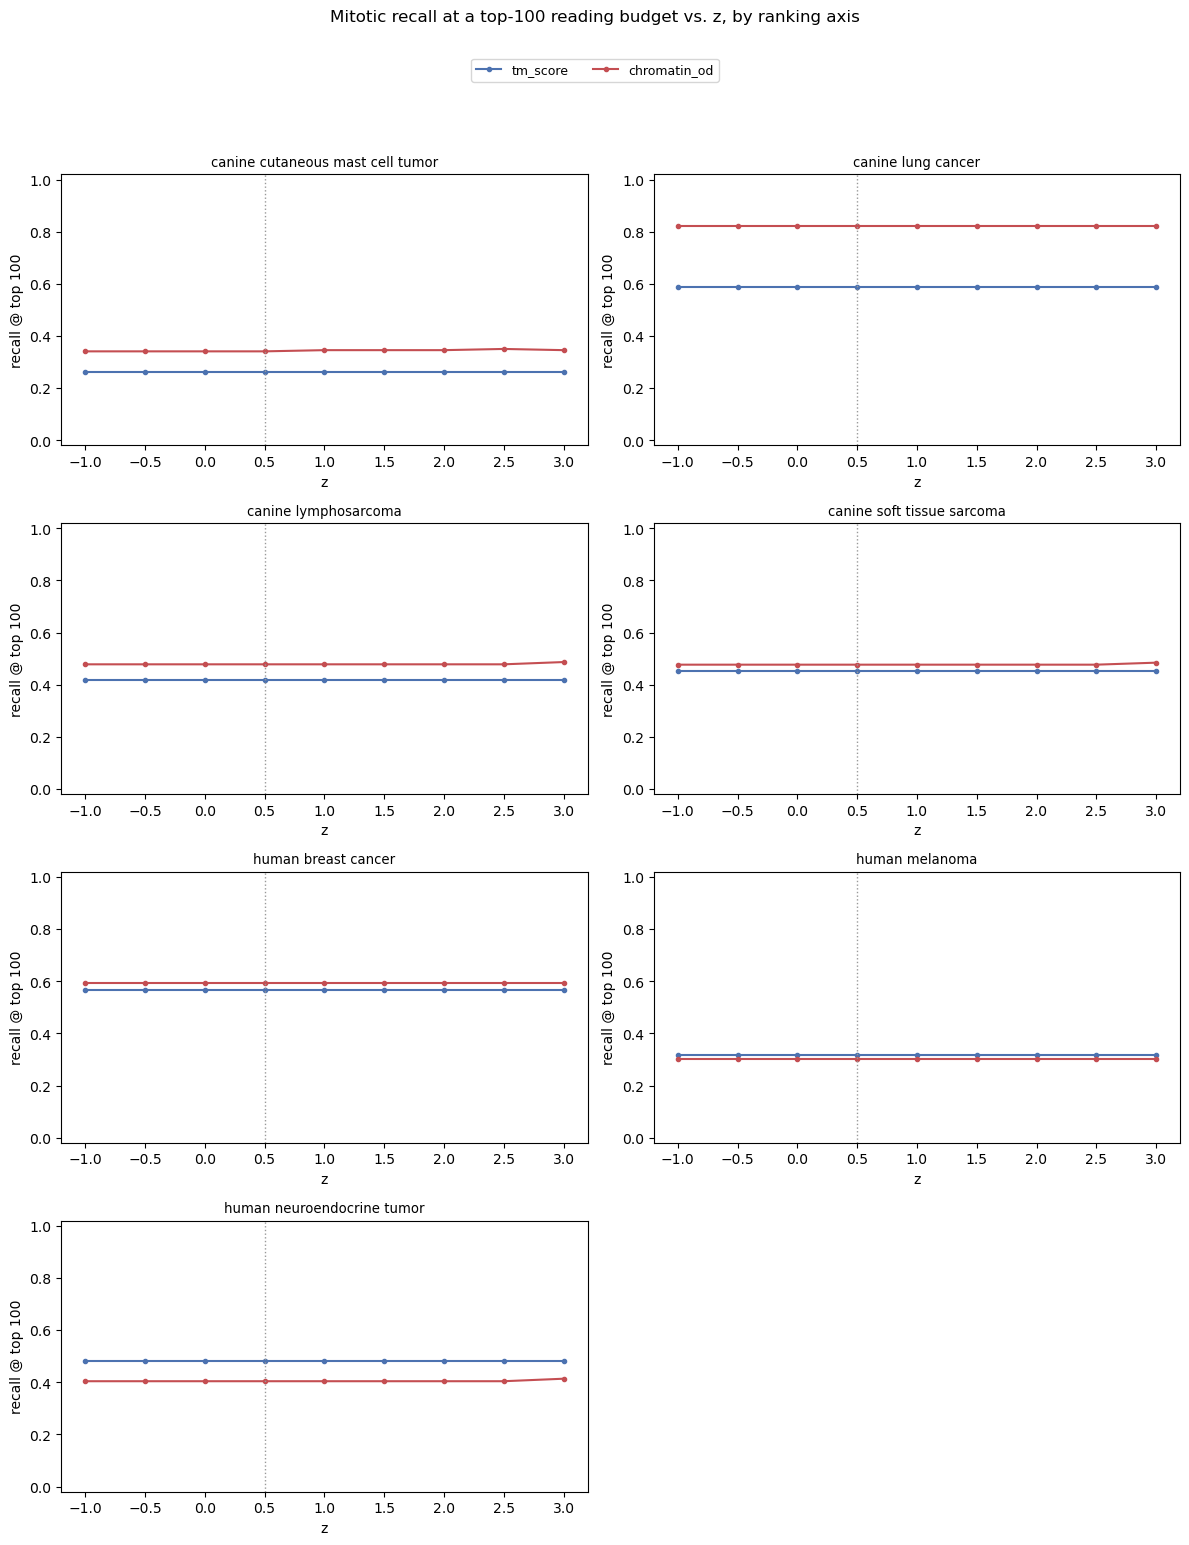

In [11]:
BUDGET_SHOWN = 100
rb = results[results['budget'] == BUDGET_SHOWN].drop_duplicates(
    ['file_name', 'tumor_type', 'arm', 'z']).copy()

fig, axes3 = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows))
axes3 = np.atleast_1d(axes3).ravel()

for ax, domain in zip(axes3, domains):
    for axis in AXES:
        d = rb[(rb['tumor_type'] == domain) & (rb['arm'] == axis)].sort_values('z')
        ax.plot(d['z'], d['recall_at_budget'], color=AXIS_COLOR[axis], marker='o',
               markersize=3, label=axis)
    ax.axvline(CURRENT_Z, color='#999999', linestyle=':', linewidth=1.0)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{domain}", fontsize=9.5)
    ax.set_xlabel('z')
    ax.set_ylabel(f'recall @ top {BUDGET_SHOWN}')

for ax in axes3[n:]:
    ax.set_visible(False)

handles, labels = axes3[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04), fontsize=9)
fig.suptitle(f'Mitotic recall at a top-{BUDGET_SHOWN} reading budget vs. z, by ranking axis',
            y=1.07, fontsize=12)
fig.tight_layout()
plt.show()

## Across-domain summary

**`median_read_95` is not comparable across `z`.** `compare._read_depths` returns `NaN` when a
recall fraction is unreachable, and this median silently drops those domains: **7** of 7
contribute at `z <= 2.0`, but only **5** at `z = 2.5` and **4** at `z = 3.0`. The domains that
drop out are exactly the ones that needed the deepest reading, so the apparent
*improvement* at `z = 2.5` (`tm_score` 3158 -> 2591, `chromatin_od` 2613 -> 1768) and the
non-monotone bounce at `z = 3.0` (1768 -> 2040.5) are survivorship, not a real drop in
reading depth. The `n_read95_*` columns below make the shrinking denominator visible;
read a row only against other rows with the same `n_read95_finite`.

Median (not mean -- see `compare.summarise`) `recall_at_budget` and `read_95` over the 7
domains, one row per `(axis, z)`, at two budgets bracketing a short pathologist read. Read
this as the single table to defend a `z` choice from: the composition figure above says how
much the candidate pool shrinks and how precision moves; this says what that shrinkage costs
in recall, at both axes, pooled across domains.

In [12]:
summary_rows = []
for budget in (50, 100, 250):
    for axis in AXES:
        sub = results[(results['budget'] == budget) & (results['arm'] == axis)]
        for z in Z_LEVELS:
            szz = sub[sub['z'] == z]
            summary_rows.append({
                'budget': budget, 'axis': axis, 'z': z,
                'median_recall_at_budget': round(float(szz['recall_at_budget'].median()), 4),
                'median_read_95': float(szz['read_95'].median()),
                'n_read95_finite': int(szz['read_95'].notna().sum()),
                'n_read95_unreachable': int(szz['read_95'].isna().sum()),
                'n_read99_unreachable': int(szz['read_99'].isna().sum()),
                'n_read100_unreachable': int(szz['read_100'].isna().sum()),
                'median_precision_full': round(
                    float((szz['full_list_recall'] * szz['n_gt_mitotic']
                          / szz['n_detections']).median()), 4),
                'median_n_detections': int(szz['n_detections'].median()),
            })
summary_table = pd.DataFrame(summary_rows)
summary_table[(summary_table['budget'] == 100)].pivot(
    index='z', columns='axis',
    values=['median_recall_at_budget', 'median_read_95', 'n_read95_finite',
            'median_n_detections'])

median_recall_at_budget          median_read_95          n_read95_finite          median_n_detections         
axis            chromatin_od tm_score   chromatin_od tm_score    chromatin_od tm_score        chromatin_od tm_score
z                                                                                                                  
-1.0                  0.4769   0.4538         2834.0   3158.0             7.0      7.0             16358.0  16358.0
-0.5                  0.4769   0.4538         2833.0   3158.0             7.0      7.0             16346.0  16346.0
 0.0                  0.4769   0.4538         2829.0   3158.0             7.0      7.0             16173.0  16173.0
 0.5                  0.4769   0.4538         2817.0   3158.0             7.0      7.0             15161.0  15161.0
 1.0                  0.4769   0.4538         2796.0   3158.0             7.0      7.0             13669.0  13669.0
 1.5                  0.4769   0.4538         2740.0   3158.0             7.0      7.0             12120.0  12120.0
 2.0                  0.4769   0.4538         2613.0   3158.0             7.0      7.0              9619.0   9619.0
 2.5                  0.4769   0.4538         1768.0   2591.0             5.0      5.0              6259.0   6259.0
 3.0                  0.4846   0.4538         2040.5   2518.5             4.0      4.0              3366.0   3366.0

## Coverage: how much of the ROI does this list already cover?

`evaluate.py`'s module docstring: *"Read `coverage_frac` before reading any full-list
number. A detection list long enough to tile the ROI answers 'is this annotation within
the match radius of some detection?' by geometry rather than by evidence."* The harness
computes it on every arm and it is saved in the CSV; it is surfaced here because every
composition and full-list-recall number above is exactly the question it guards.

Below it, the duplicate-detection count from the main loop: detections that sit inside
some ground truth's match circle but are bucketed `non_human_findings`, because a
higher-ranked detection already claimed that annotation. These are false positives that
are really duplicates.

In [13]:
cov = (results[results['arm'] == 'tm_score']
       .drop_duplicates(['file_name', 'z'])
       .pivot(index='tumor_type', columns='z', values='coverage_frac'))
print('coverage_frac -- fraction of ARBITRARY ROI locations already within the match')
print('radius of some detection. Read before any full-list number (evaluate.py docstring).')
display(cov.round(4))

print('\nDuplicate detections inside a ground-truth match circle, at the deep floor.')
print('NMS ran at the evaluation match radius here (invariant-compliant); the v2 notebook')
print('decouples them and this is the baseline it should be compared against.')
display(diag_df.assign(dup_fp_pct=(100 * diag_df['n_dup_fp'] / diag_df['n_detections']).round(2)))

coverage_frac -- fraction of ARBITRARY ROI locations already within the match
radius of some detection. Read before any full-list number (evaluate.py docstring).


z,-1.0,-0.5,0.0,0.5,1.0,1.5,2.0,2.5,3.0
tumor_type,,,,,,,,,
canine cutaneous mast cell tumor,0.9496,0.9493,0.9473,0.9387,0.9169,0.8615,0.7265,0.5014,0.2732
canine lung cancer,0.9293,0.9283,0.9212,0.8929,0.8378,0.7384,0.5900,0.4178,0.2556
canine lymphosarcoma,0.9505,0.9504,0.9493,0.9447,0.9261,0.8637,0.7060,0.4679,0.2647
canine soft tissue sarcoma,0.9265,0.9260,0.9187,0.8947,0.8549,0.7935,0.6759,0.4817,0.2782
human breast cancer,0.9442,0.9437,0.9401,0.8912,0.8391,0.7820,0.6932,0.5717,0.4307
human melanoma,0.9266,0.9261,0.9193,0.8866,0.8320,0.7696,0.6767,0.5351,0.3735
human neuroendocrine tumor,0.9371,0.9367,0.9324,0.9181,0.8871,0.8093,0.6475,0.4358,0.2576



Duplicate detections inside a ground-truth match circle, at the deep floor.
NMS ran at the evaluation match radius here (invariant-compliant); the v2 notebook
decouples them and this is the baseline it should be compared against.


,file_name,tumor_type,n_detections,n_within_match_radius,n_dup_fp,dup_fp_pct
0,301.tiff,canine cutaneous mast cell tumor,17316,424,111,0.64
1,201.tiff,canine lung cancer,15549,71,5,0.03
2,246.tiff,canine lymphosarcoma,17397,299,63,0.36
3,459.tiff,canine soft tissue sarcoma,15445,233,15,0.10
4,094.tiff,human breast cancer,16755,216,33,0.20
5,548.tiff,human melanoma,15897,397,41,0.26
6,402.tiff,human neuroendocrine tumor,16360,218,35,0.21


**What this sweep actually found.**

1. **The extraction floor is not a product-relevant knob anywhere in the range swept.**
   At every budget where the candidate pool never truncates (every value in
   `compare.BUDGETS` except 5000, here), moving `z` from -1.0 to 3.0 changes
   `recall_at_budget` -- the metric `compare.py` designates as primary -- by **exactly
   zero** on the `tm_score` axis, in every domain, and by at most **0.0096** on
   `chromatin_od` (in 4 of 7 domains; exactly 0 in the other 3). The first is an
   identity, asserted above; the second is a real but negligible effect. What `z` does
   change is candidate *volume* and ROI *coverage*, which is a cost question, not a
   recall question.

2. **The full-list numbers are coverage-saturated and must be read with the coverage
   table.** At `z <= 0.5` these lists put a detection within the match radius of
   89-95% of *arbitrary* ROI locations. `evaluate.py`'s module docstring is explicit
   that any un-budgeted metric is that question rather than a detector result.

3. **Reading depth is where the cost lives, and it is under-powered here.** `read_95`
   separates the domains far more than `z` does. But with one seed per domain, the
   per-domain differences are inside the seed noise quoted in the configuration
   section, and `median_read_95` cannot be compared across `z` at all (see the
   survivorship note above).

**What this does not settle.** Whether `chromatin_od` re-ranking is worth adopting: it
is ahead of `tm_score` on `read_95` at every `z` here, but on one seed per domain, and
its own read-depth columns are the ones most exposed to the border-`NaN` issue that
`tm_threshold_axis_sweep_v2.ipynb` later introduced and
`tm_threshold_axis_sweep_largest_cc.ipynb` diagnosed. The per-domain breakdown behind
all of the above is saved to `results/tm_ccoeff_threshold_axis_sweep.csv`.
